#### Problem Statement: The objective of this project is to develop a machine learning classification model using XGBoost to predict the price range of a mobile phone based on its technical specifications, such as RAM, battery power, internal memory, camera specifications, screen resolution, processor-related features, connectivity, and other hardware characteristics.

#### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

%pip install xgboost

from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.


#### Understand the dataset

In [2]:
df=pd.read_csv(r"Mobile_price_range.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### Exploratory Data analysis(EDA)

##### check null values

In [6]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

##### check duplicate values

In [7]:
df.duplicated().sum()

np.int64(0)

##### Check Traget Distribution

In [10]:
print(df['price_range'].value_counts().sort_index())

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


##### Check For Outliers

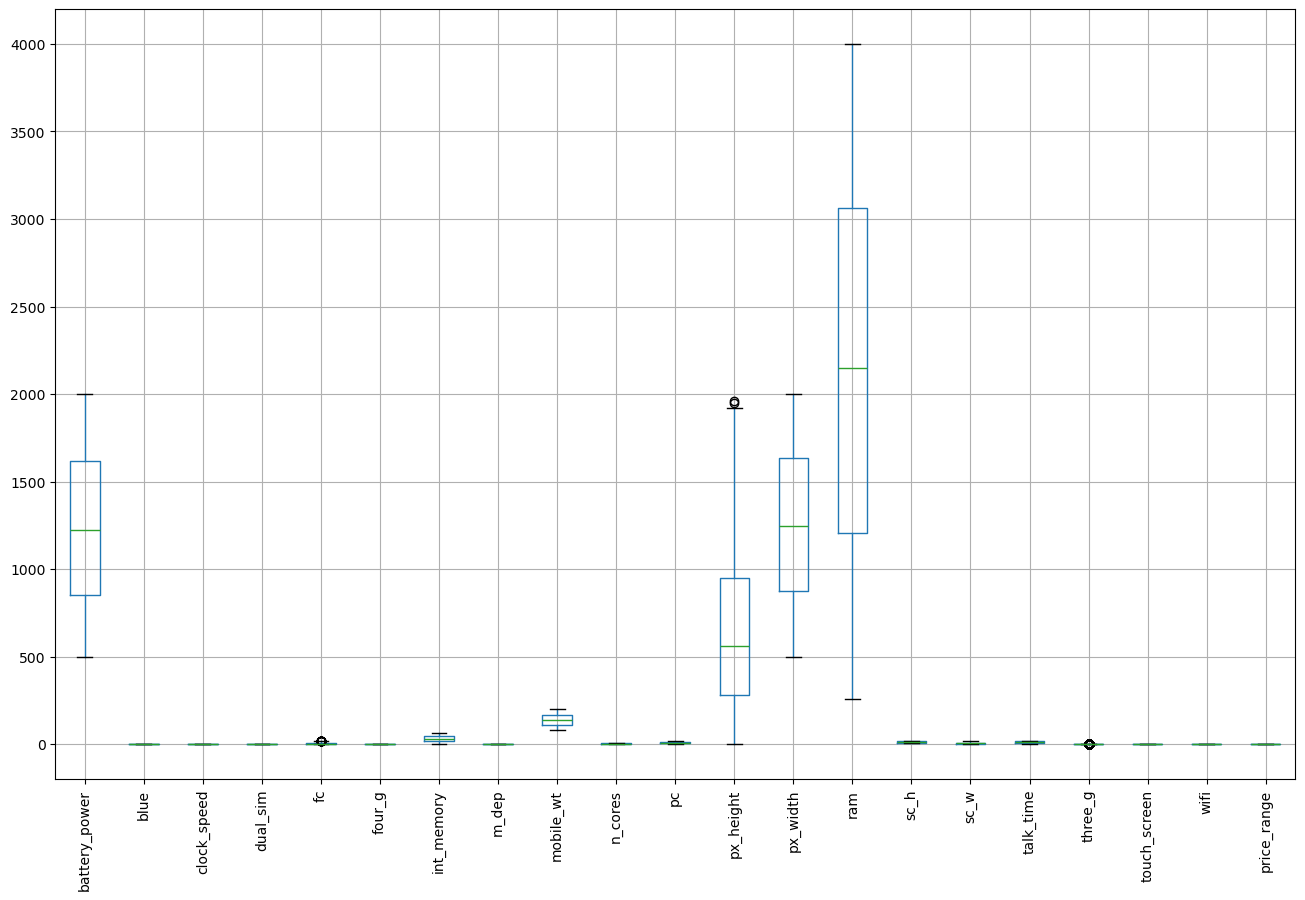

In [13]:
df.boxplot(figsize=(16,10))
plt.xticks(rotation=90)
plt.show()

### Find Correlation between the columns

ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
touch_screen    -0.030411
mobile_wt       -0.030302
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
clock_speed     -0.006606
n_cores          0.004399
m_dep            0.000853
Name: price_range, dtype: float64


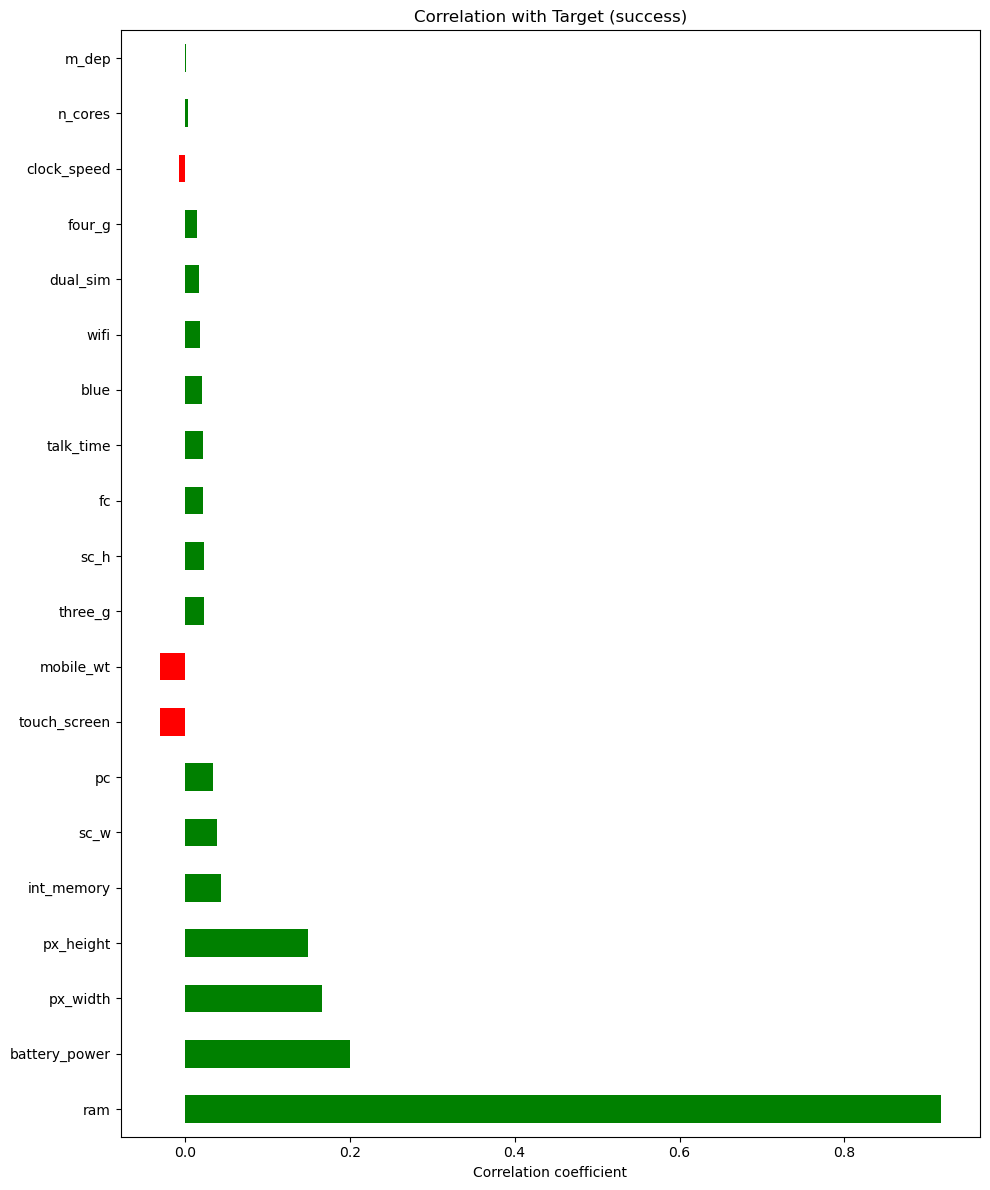

In [21]:
numeric_df = df.select_dtypes(include=[int,float])
target_corr = numeric_df.corr()['price_range'].drop('price_range').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(10,12))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (success)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

In [24]:
selected_features=['ram','battery_power','px_width',
                    'px_height','int_memory','sc_w',
                    'pc','touch_screen','mobile_wt','three_g']

selected_features

['ram',
 'battery_power',
 'px_width',
 'px_height',
 'int_memory',
 'sc_w',
 'pc',
 'touch_screen',
 'mobile_wt',
 'three_g']

#### Define X and y

In [25]:
X=df[selected_features]

y=df['price_range']

#### Train test split

In [27]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

#### Create XG Model

In [28]:
model=XGBClassifier(random_state=42)
model.fit(Xtest,ytest)
ypred=model.predict(Xtest)

### Evaluate the model

In [29]:
print(f'train Accuracy: {model.score(Xtrain, ytrain)}')
print(f'test Accuracy: {model.score(Xtest, ytest)}')

train Accuracy: 0.851875
test Accuracy: 1.0


In [31]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        91
           2       1.00      1.00      1.00        92
           3       1.00      1.00      1.00       112

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



#### Hyperparameter Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

##### 1.estimator tells RandomizedSearchCV:"Which machine learningmodel should I tune?"
##### 2.param_distributions=params "These are the hyperparameters and possible values I want you to try"
##### 3.n_iter=20 "Try 20 different randomly selected combinations of hyperparameters."
##### 4.scoring="accuracy" "Use accuracy to decide which hyperparameter combination performs better."
##### 5.cv=3 cv means Cross-Validation.
##### 6.n_jobs=-1 This controls the number of CPU cores used.
##### 7.verbose=1 This controls how much progress information is printed while RandomizedSearchCV running.


In [ ]:
xgb = XGBClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=xgb,                
    param_distributions=params,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [38]:
random_search.fit(Xtrain,ytrain)
random_search.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


{'subsample': 0.9,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.2,
 'gamma': 0.1,
 'colsample_bytree': 1.0}

In [41]:
final_model=XGBClassifier(subsample=0.9,n_estimators=200,min_child_weight=5,max_depth=3,
                          learning_rate=0.2, gamma=0.1,colsample_bytree=1.0,random_state=42)

final_model.fit(Xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [43]:
print(f'train Accuracy: {final_model.score(Xtrain, ytrain)}')
print(f'test Accuracy: {final_model.score(Xtest, ytest)}')

train Accuracy: 1.0
test Accuracy: 0.925


**Conclusion**: The XGBoost classification model was successfully developed to predict the target variable using the given dataset. After data preprocessing and model training, the final XGBoost model achieved:

Training Accuracy: 100%
Testing Accuracy: 92.5%

The 92.5% test accuracy indicates that the model performs well on unseen data and has learned useful patterns from the dataset. 

The project demonstrates an end-to-end machine learning workflow including data cleaning, feature preparation, model training, hyperparameter tuning, and model evaluation. XGBoost was effective because it combines multiple decision trees sequentially and focuses on correcting errors made by previous trees.